In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression

from sklearn.preprocessing import StandardScaler

from sklearn.metrics import mean_squared_error as MSE

from sklearn.preprocessing import MinMaxScaler

from sklearn.metrics import r2_score



In [3]:
df = pd.read_csv('california_housing_data.csv')

In [4]:
df.head(30)

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422
5,4.0368,52.0,4.761658,1.103627,413.0,2.139896,37.85,-122.25,2.697
6,3.6591,52.0,4.931907,0.951362,1094.0,2.128405,37.84,-122.25,2.992
7,3.1200,52.0,4.797527,1.061824,1157.0,1.788253,37.84,-122.25,2.414
8,2.0804,42.0,4.294118,1.117647,1206.0,2.026891,37.84,-122.26,2.267
9,3.6912,52.0,4.970588,0.990196,1551.0,2.172269,37.84,-122.25,2.611


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


**train test split**
\nEstraggo le features e il target (prezzo mediano) dal data frame e divido in train e test con una rapporto 80:30.

In [29]:
X = df[df.columns[:-2]]
y = np.array(df['MedHouseVal'])

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

Normalizzazione riportando a media 0 e var 1.

In [30]:
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

In [10]:
y_train_s = scaler.fit_transform(y_train.reshape(-1,1)).flatten()
y_test_s = scaler.transform(y_test.reshape(-1,1)).flatten()

In [11]:
regression = LinearRegression()

regression.fit(X_train_s, y_train_s)


LinearRegression()

In [12]:
y_pred_s = regression.predict(X_test_s)

In [13]:
errore = MSE(y_test_s, y_pred_s)

print("Mean Squared Error (su variabbili standardizzate):", errore)

y_pred = scaler.inverse_transform(y_pred_s.reshape(-1,1)).flatten()

errore = MSE(y_test, y_pred)

print("Mean Squared Error:", errore)

r2 = r2_score(y_test, y_pred)
print("R2 Score:", r2)

Mean Squared Error (su variabbili standardizzate): 0.4563416008651703
Mean Squared Error: 0.6113590070321648
R2 Score: 0.5342168948646984


**regressione senza normalizzare i target**

In [14]:
regression.fit(X_train_s, y_train)
pred = regression.predict(X_test_s)
errore = MSE(y_test, pred )

print("Mean Squared Error:", errore)

Mean Squared Error: 0.6113590070321648


Normalizzare o meno il target non altera le prestazioni, in effetti in valore assoluto non è molto grande.

In [15]:
print(f"La media dil prezzo delle case nel test set è: {np.mean(y_test):.3f}, la deviazione standard è: {np.std(y_test):.3f}, il valore massimo è: {np.max(y_test):.3f} e il valore minimo è: {np.min(y_test):.3f}")
print(f"la media del prezzo nel train set predetto è: {np.mean(y_train):.3f}, la deviazione standard è: {np.std(y_train):.3f}, il valore massimo è: {np.max(y_train):.3f} e il valore minimo è: {np.min(y_train):.3f}")
print(f"la media del prezzo nel test set predetto è: {np.mean(y_pred):.3f}, la deviazione standard è: {np.std(y_pred):.3f}, il valore massimo è: {np.max(y_pred):.3f} e il valore minimo è: {np.min(y_pred):.3f}")

La media dil prezzo delle case nel test set è: 2.067, la deviazione standard è: 1.146, il valore massimo è: 5.000 e il valore minimo è: 0.150
la media del prezzo nel train set predetto è: 2.069, la deviazione standard è: 1.157, il valore massimo è: 5.000 e il valore minimo è: 0.150
la media del prezzo nel test set predetto è: 2.066, la deviazione standard è: 0.848, il valore massimo è: 10.753 e il valore minimo è: -0.296


**Normalizzazione fra 0 e 1**

In [16]:
scaler = MinMaxScaler()
X_train_s = scaler.fit_transform(X_train) 
X_test_s = scaler.transform(X_test) 

In [17]:
regression.fit(X_train_s, y_train)
pred = regression.predict(X_test_s)
errore = MSE(y_test, pred)

print("Mean Squared Error:", errore)

Mean Squared Error: 0.6113590070321644


Generazione del grafico in corso...


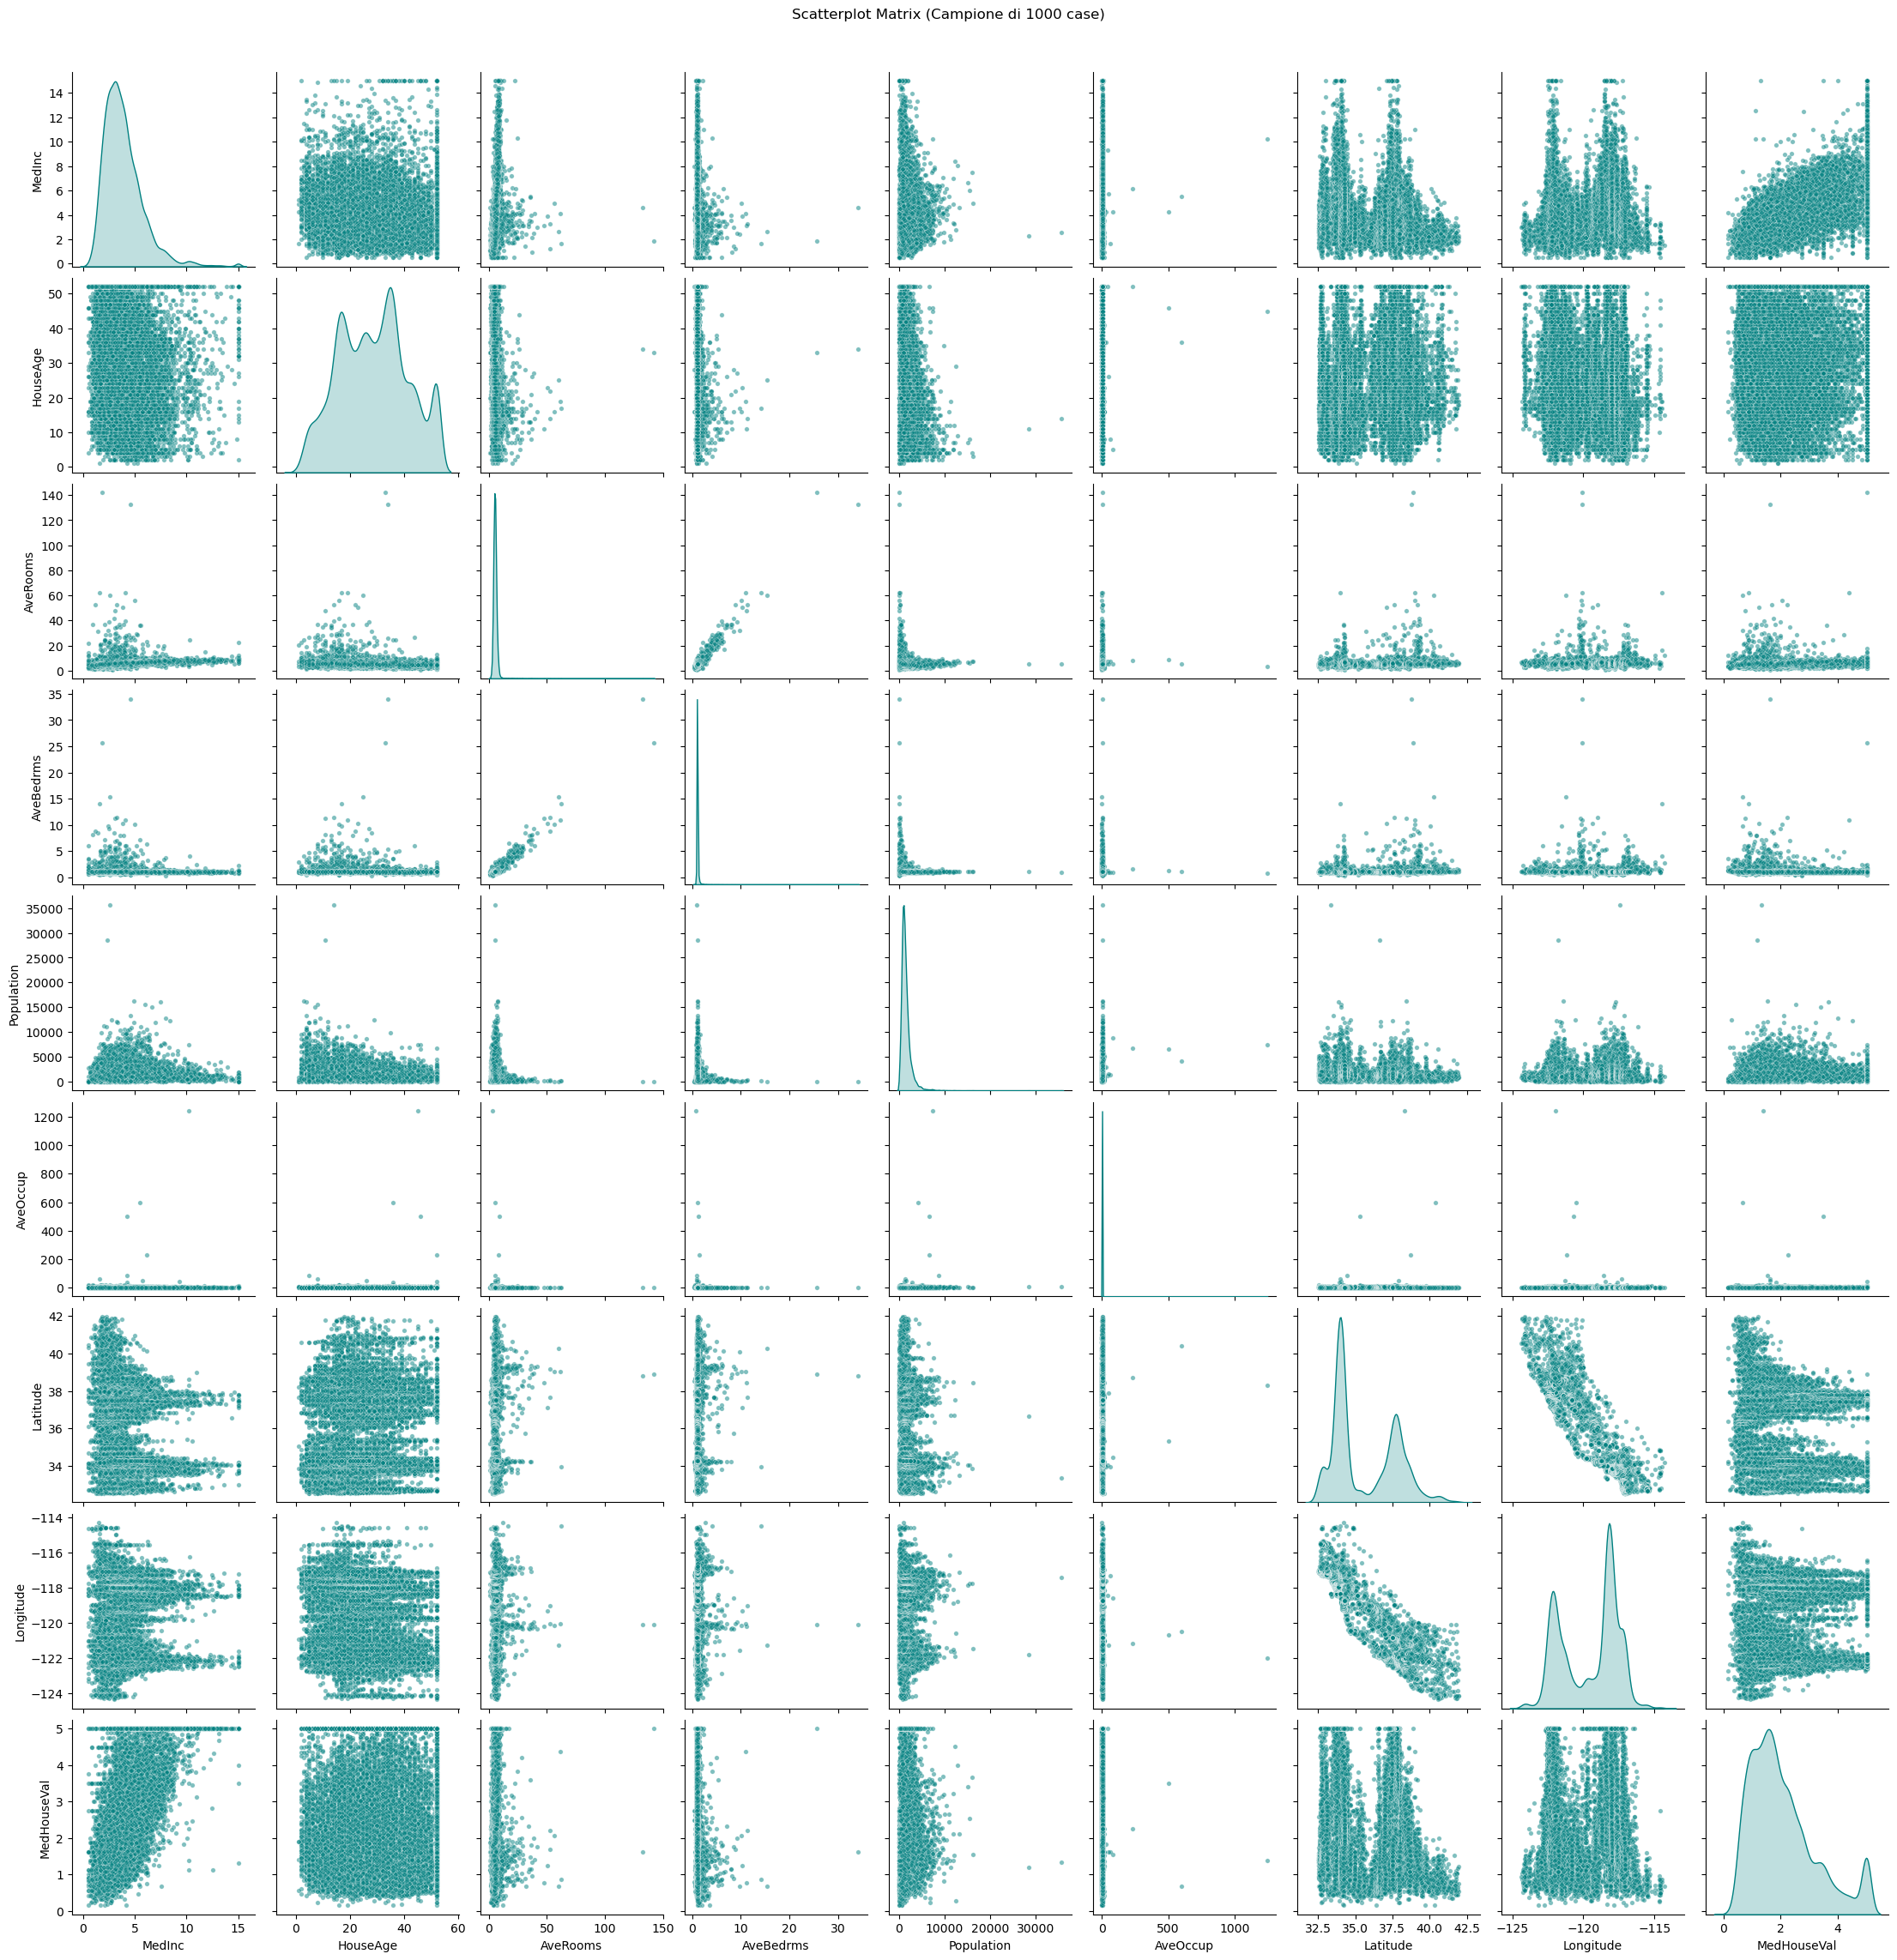

In [18]:

# 3. Creazione del Pairplot
# kind='scatter': usa i punti per le relazioni
# diag_kind='kde': usa le curve di densità sulla diagonale (invece degli istogrammi)
# plot_kws={'alpha': 0.5}: rende i punti semi-trasparenti per vedere le sovrapposizioni
print("Generazione del grafico in corso...")
g = sns.pairplot(df, 
                 diag_kind='kde', 
                 plot_kws={'alpha': 0.5, 's': 15, 'color': 'teal'},
                 diag_kws={'color': 'teal', 'fill': True},
                 height=2.5)

g.fig.suptitle('Scatterplot Matrix (Campione di 1000 case)', y=1.02)
plt.show()

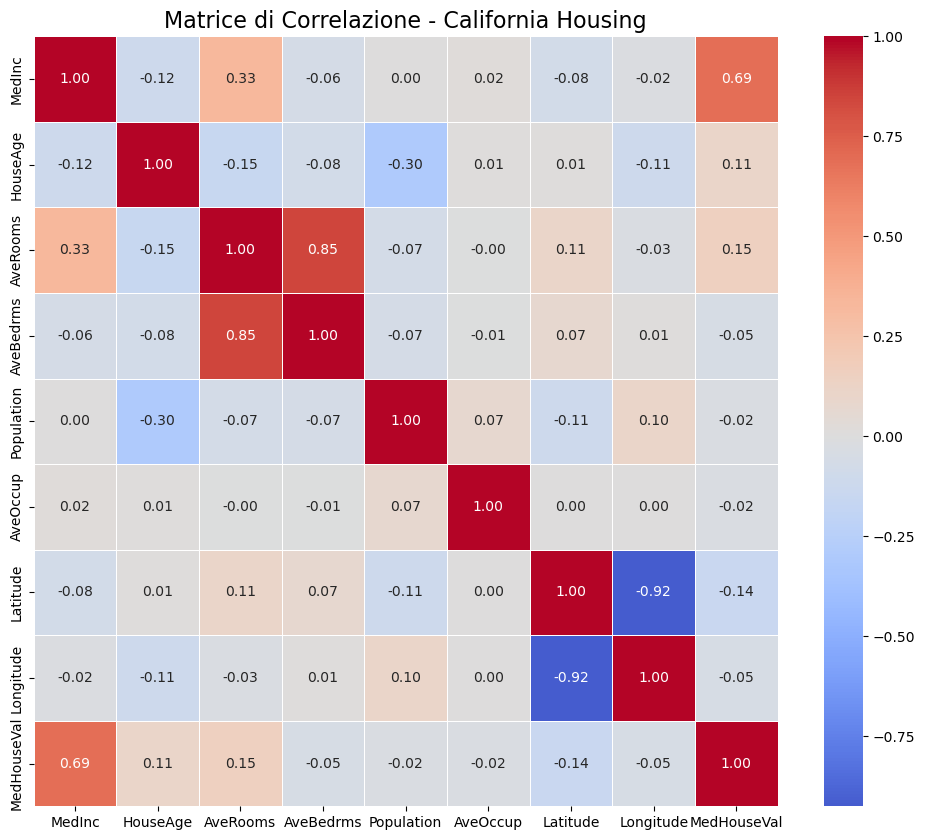

In [19]:
# 1. Calcolo la matrice di correlazione (coefficiente di Pearson)
# Nota: Se hai 'df_clean' dall'analisi precedente usa quello, altrimenti usa 'df'
corr_matrix = df.corr()

# 2. Setup della figura
plt.figure(figsize=(12, 10))

# 3. Creazione della Heatmap
# annot=True: scrive i numeri nelle celle
# cmap='coolwarm': Rosso=Positivo, Blu=Negativo, Bianco=Neutro
# fmt=".2f": arrotonda a 2 decimali per leggibilità
sns.heatmap(corr_matrix, 
            annot=True, 
            cmap='coolwarm', 
            center=0, 
            linewidths=0.5, 
            linecolor='white',
            fmt=".2f")

plt.title('Matrice di Correlazione - California Housing', fontsize=16)
plt.show()

**Rimozione degli Outliers**

In [16]:
df = pd.read_csv('california_housing_data.csv')

In [17]:
X = df[df.columns[:-2]]
y = np.array(df['MedHouseVal'])
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [14]:
for col in X_train.columns:

    # 2. Definizione dei limiti
    lower_bound = X_train[col].quantile(0.05)
    upper_bound = X_train[col].quantile(0.95)

    print(f"Intervallo 'Normale' per {col}: da {lower_bound:.2f} a {upper_bound:.2f}")

    # 3. Individuazione degli Outlier
    outliers_iqr = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    print(f"Numero di Outlier rilevati con IQR: {len(outliers_iqr)}")
    print(f"Percentuale sul totale: {len(outliers_iqr)/len(df)*100:.2f}%")

    # Vediamo alcuni di questi outlier estremi
    print("\nEsempi di outlier estremi:")
    print(outliers_iqr[col].sort_values(ascending=False).head(5))
    
    print()
    print("-" * 50)

Intervallo 'Normale' per MedInc: da 1.60 a 7.31
Numero di Outlier rilevati con IQR: 2055
Percentuale sul totale: 9.96%

Esempi di outlier estremi:
5242     15.0001
10673    15.0001
10760    15.0001
4626     15.0001
5291     15.0001
Name: MedInc, dtype: float64

--------------------------------------------------
Intervallo 'Normale' per HouseAge: da 8.00 a 52.00
Numero di Outlier rilevati con IQR: 894
Percentuale sul totale: 4.33%

Esempi di outlier estremi:
922      7.0
20527    7.0
13721    7.0
13467    7.0
1347     7.0
Name: HouseAge, dtype: float64

--------------------------------------------------
Intervallo 'Normale' per AveRooms: da 3.44 a 7.65
Numero di Outlier rilevati con IQR: 2067
Percentuale sul totale: 10.01%

Esempi di outlier estremi:
1914     141.909091
1979     132.533333
12447     62.422222
1913      61.812500
11862     59.875000
Name: AveRooms, dtype: float64

--------------------------------------------------
Intervallo 'Normale' per AveBedrms: da 0.94 a 1.28
Numero

In [15]:
for col in X_train.columns:
    lower_bound = df[col].quantile(0.05)
    upper_bound = df[col].quantile(0.95)
    
    mask = (df[col] < lower_bound) | (df[col] > upper_bound)
    X_train = X_train[~mask] #drop degli outlier"""
    y_train = y_train[~mask]

C:\Users\m-rog\AppData\Local\Temp\ipykernel_12736\4149035290.py:6: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  X_train = X_train[~mask] #drop degli outlier"""


IndexError: boolean index did not match indexed array along axis 0; size of axis is 16512 but size of corresponding boolean axis is 20640

In [ ]:
df["MedHouseVal"] = np.log(df["MedHouseVal"])

In [105]:
df.columns

Index(['MedInc', 'HouseAge', 'AveOccup', 'Latitude', 'Longitude',
       'MedHouseVal', 'Rooms_per_person', 'Bedrooms_per_person',
       'BedRooms_per_room'],
      dtype='object')

In [135]:
df["Rooms_per_person"] = df["AveRooms"] / df["AveOccup"]
df["Bedrooms_per_person"] = df["AveBedrms"] / df["AveOccup"]
df["BedRooms_per_room"] = df["AveBedrms"] / df["AveRooms"]

In [136]:
df = df.drop(columns=['AveBedrms','AveRooms','AveOccup'])  

In [106]:
for col in df.columns:
    # 1. Calcolo dei Quartili
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    # 2. Definizione dei limiti
    lower_bound = Q1 - 1.5 * IQR 
    upper_bound = Q3 + 1.5 * IQR

    print(f"Intervallo 'Normale' per {col}: da {lower_bound:.2f} a {upper_bound:.2f}")

    # 3. Individuazione degli Outlier
    outliers_iqr = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    print(f"Numero di Outlier rilevati con IQR: {len(outliers_iqr)}")
    print(f"Percentuale sul totale: {len(outliers_iqr)/len(df)*100:.2f}%")

    # Vediamo alcuni di questi outlier estremi
    print("\nEsempi di outlier estremi:")
    print(outliers_iqr[col].sort_values(ascending=False).head(5))
    
    print()
    print("-" * 50)

Intervallo 'Normale' per MedInc: da -0.71 a 8.01
Numero di Outlier rilevati con IQR: 681
Percentuale sul totale: 3.30%

Esempi di outlier estremi:
1566     15.0001
17858    15.0001
17170    15.0001
17108    15.0001
17107    15.0001
Name: MedInc, dtype: float64

--------------------------------------------------
Intervallo 'Normale' per HouseAge: da -10.50 a 65.50
Numero di Outlier rilevati con IQR: 0
Percentuale sul totale: 0.00%

Esempi di outlier estremi:
Series([], Name: HouseAge, dtype: float64)

--------------------------------------------------
Intervallo 'Normale' per AveOccup: da 1.15 a 4.56
Numero di Outlier rilevati con IQR: 711
Percentuale sul totale: 3.44%

Esempi di outlier estremi:
19006    1243.333333
3364      599.714286
16669     502.461538
13034     230.172414
9172       83.171429
Name: AveOccup, dtype: float64

--------------------------------------------------
Intervallo 'Normale' per Latitude: da 28.26 a 43.38
Numero di Outlier rilevati con IQR: 0
Percentuale sul t

In [ ]:
good_col = ["AveRooms","AveBedrms","AveOccup",'Latitude', 'Longitude']
for col in X_test.columns:
    # 1. Calcolo dei Quartili
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    # 2. Definizione dei limiti
    lower_bound = Q1 - 1.5 * IQR 
    upper_bound = Q3 + 1.5 * IQR
    
    mask = (df[col] < lower_bound) | (df[col] > upper_bound)
    df = df[~mask] #drop degli outlier

In [71]:
bad_col = ['MedInc', 'HouseAge', 'Population',
        'MedHouseVal']

for col in bad_col:

    # 2. Definizione dei limiti
    lower_bound = df[col].quantile(0.1)
    upper_bound = df[col].quantile(0.95)

    print(f"Intervallo 'Normale' per {col}: da {lower_bound:.2f} a {upper_bound:.2f}")

    # 3. Individuazione degli Outlier
    outliers_iqr = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    print(f"Numero di Outlier rilevati con IQR: {len(outliers_iqr)}")
    print(f"Percentuale sul totale: {len(outliers_iqr)/len(df)*100:.2f}%")

    # Vediamo alcuni di questi outlier estremi
    print("\nEsempi di outlier estremi:")
    print(outliers_iqr[col].sort_values(ascending=False).head(5))
    
    print()
    print("-" * 50)

Intervallo 'Normale' per MedInc: da 1.96 a 7.20
Numero di Outlier rilevati con IQR: 2751
Percentuale sul totale: 15.00%

Esempi di outlier estremi:
10760    15.0001
4604     15.0001
10673    15.0001
11520    15.0001
18501    15.0001
Name: MedInc, dtype: float64

--------------------------------------------------
Intervallo 'Normale' per HouseAge: da 13.00 a 52.00
Numero di Outlier rilevati con IQR: 1713
Percentuale sul totale: 9.34%

Esempi di outlier estremi:
576      12.0
10888    12.0
10546    12.0
11463    12.0
999      12.0
Name: HouseAge, dtype: float64

--------------------------------------------------
Intervallo 'Normale' per Population: da 573.00 a 3281.00
Numero di Outlier rilevati con IQR: 2750
Percentuale sul totale: 14.99%

Esempi di outlier estremi:
13139    16305.0
10309    16122.0
6057     15507.0
6066     15037.0
12215    13251.0
Name: Population, dtype: float64

--------------------------------------------------
Intervallo 'Normale' per MedHouseVal: da 0.85 a 4.73
Nu

In [142]:
for col in df.columns:
    lower_bound = df[col].quantile(0.1)
    upper_bound = df[col].quantile(0.95)
    
    mask = (df[col] < lower_bound) | (df[col] > upper_bound)
    df = df[~mask] #drop degli outlier"""
    

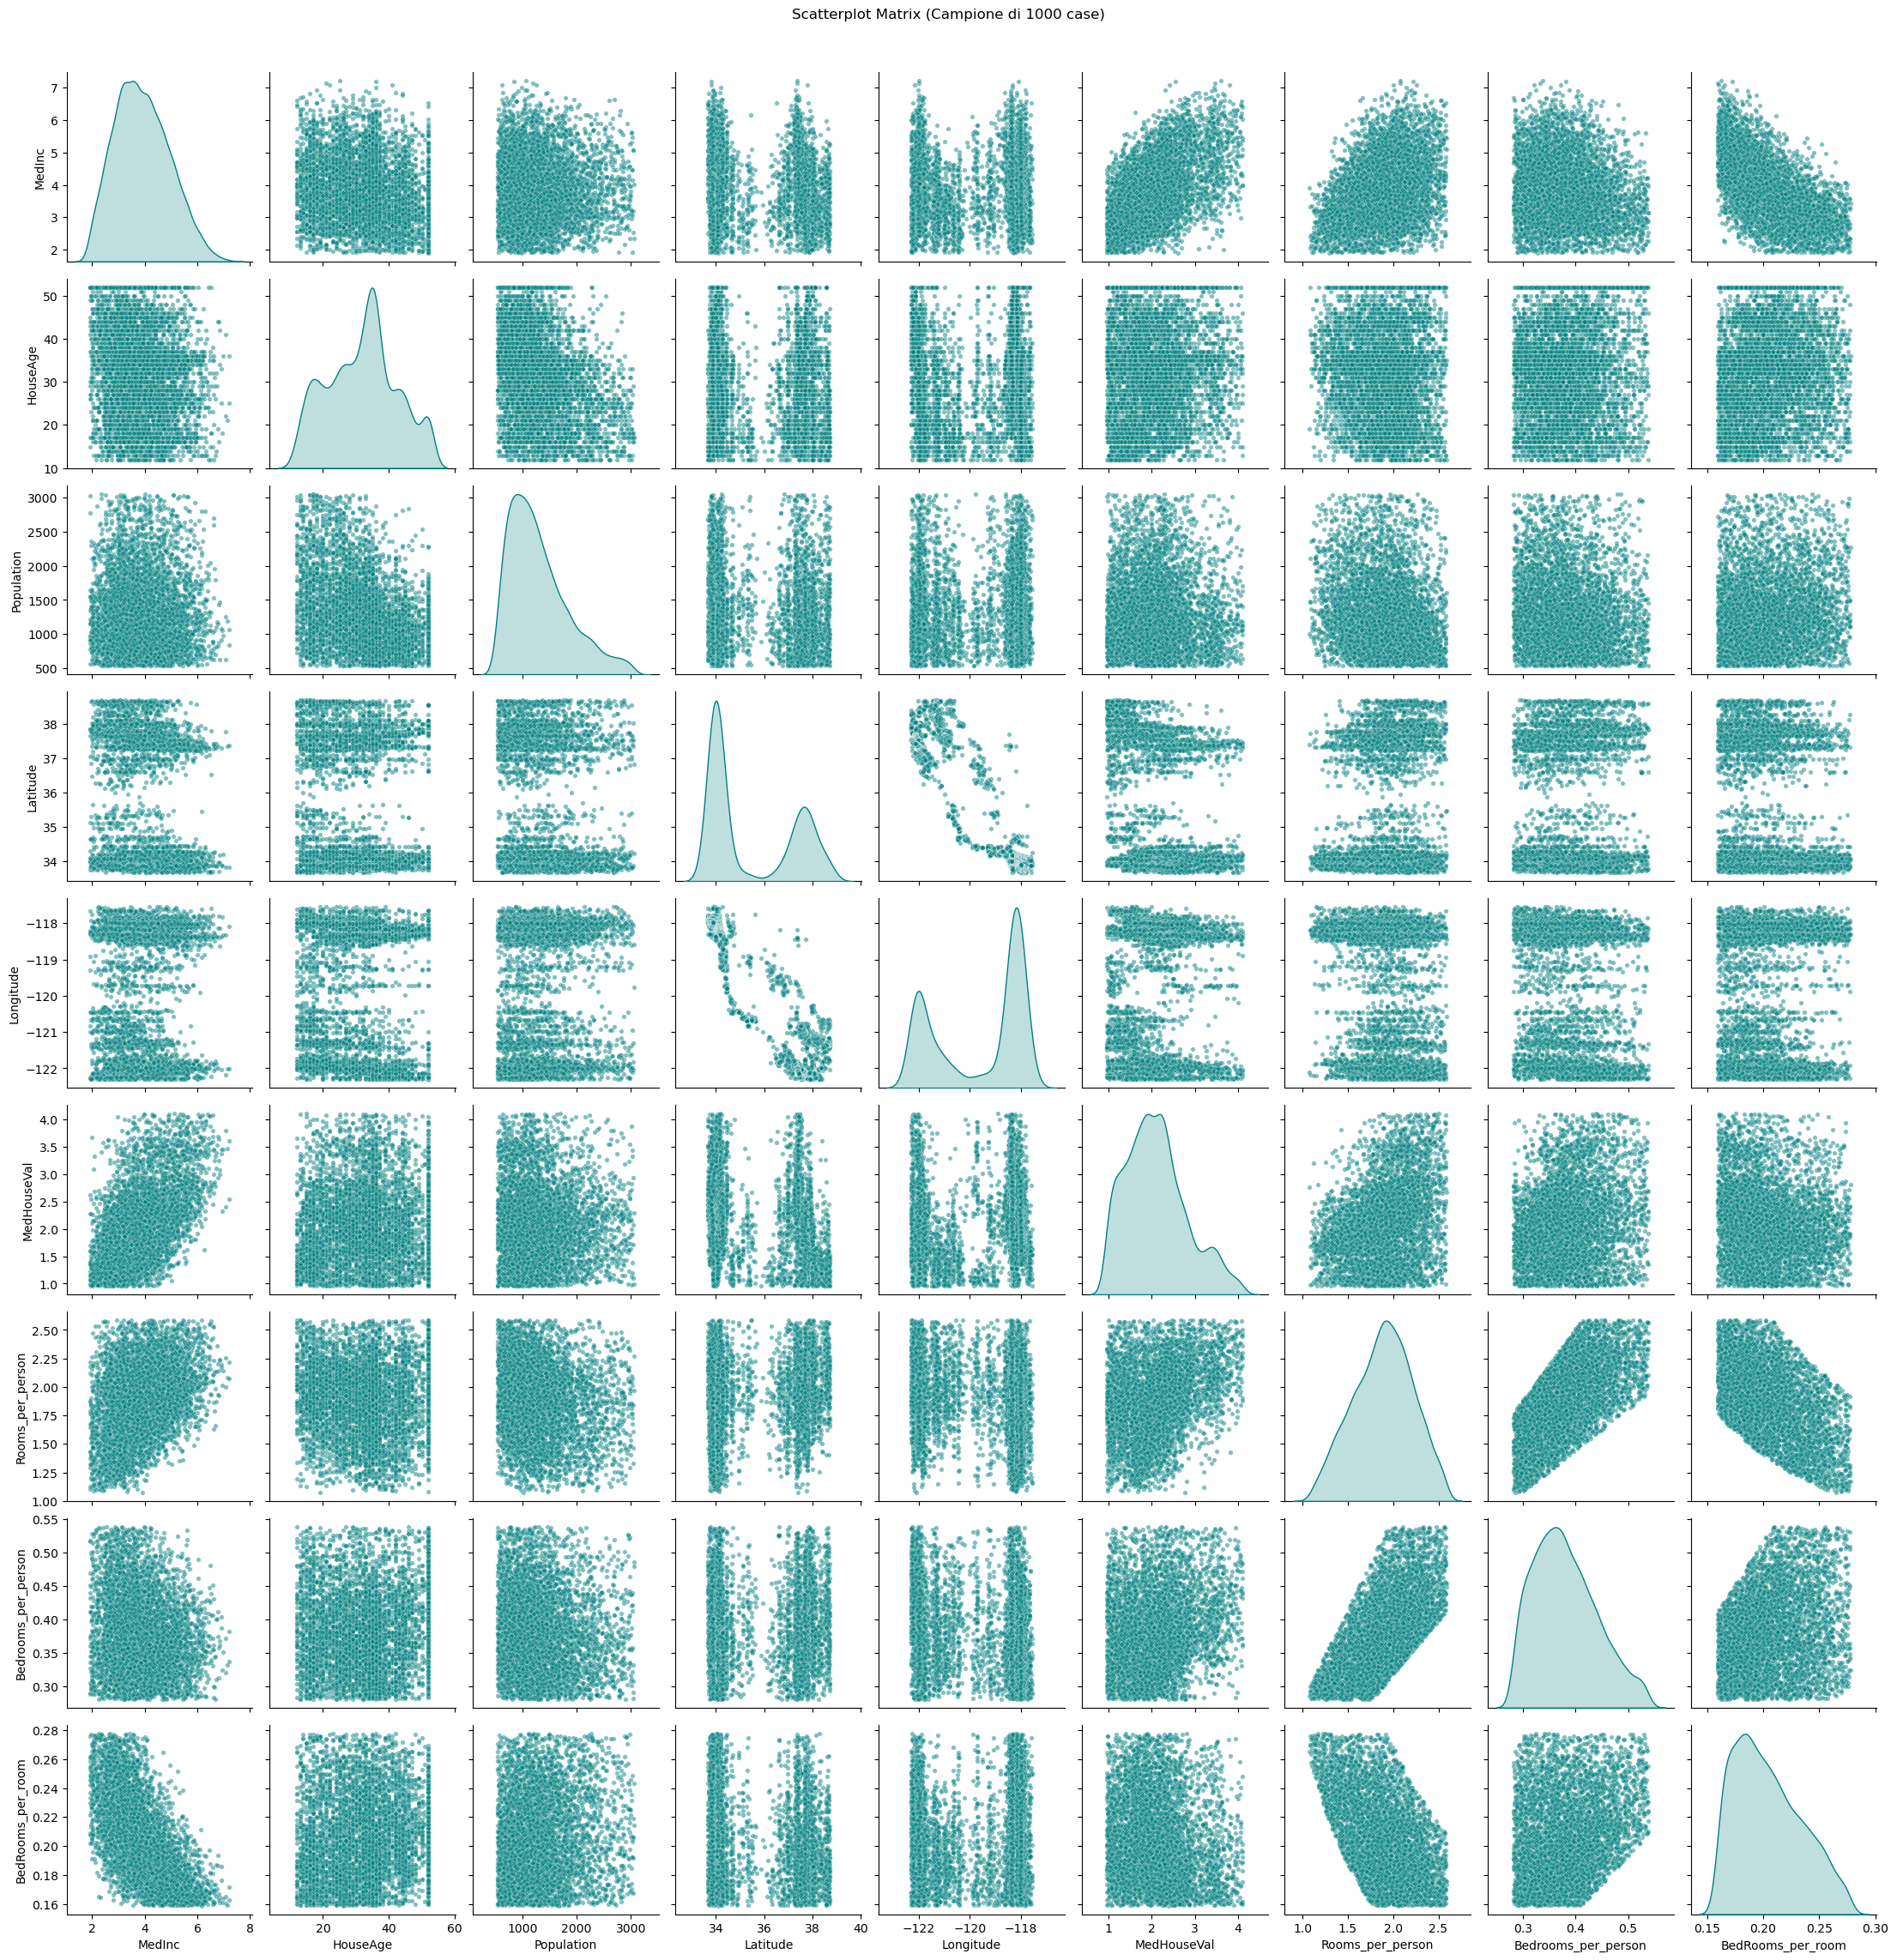

In [147]:

g = sns.pairplot(df, 
                 diag_kind='kde', 
                 plot_kws={'alpha': 0.5, 's': 15, 'color': 'teal'},
                 diag_kws={'color': 'teal', 'fill': True},
                 height=2.5)

g.fig.suptitle('Scatterplot Matrix (Campione di 1000 case)', y=1.02)
plt.show()

In [143]:
X = df[df.columns[:-2]]
y = np.array(df['MedHouseVal'])

,MedInc,HouseAge,Population,Latitude,Longitude,MedHouseVal,Rooms_per_person
18231,3.8003,23.0,2699.0,37.42,-122.09,2.298,1.805854
605,3.0964,31.0,2999.0,37.69,-122.07,1.905,1.971991
18182,3.8125,30.0,556.0,37.37,-122.03,3.250,2.282374
16437,3.1917,21.0,533.0,38.07,-121.29,2.045,2.223265
5659,4.1940,47.0,1130.0,33.73,-118.30,2.939,2.523894
...,...,...,...,...,...,...,...
17916,3.2048,33.0,1469.0,37.36,-121.99,2.618,1.822328
1258,3.6694,17.0,1169.0,38.03,-121.63,2.094,2.180496
10117,3.7933,25.0,1702.0,33.93,-117.93,1.844,1.428320
13072,2.5000,22.0,733.0,38.57,-121.31,1.016,1.676671


In [145]:
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

In [ ]:
pred_train = regression.predict(X_train_s)

errore_train = MSE(y_train, pred_train)
r2_train = r2_score(y_train, pred_train)

print("R2 Score sul train:", r2_train)
print("Mean Squared Error sul train:", errore_train)

In [9]:
regression.fit(X_train_s, y_train)
pred = regression.predict(X_test_s)

errore = MSE(y_test, pred)
r2 = r2_score(y_test, pred)

print("R2 Score:", r2)
print("Mean Squared Error:", errore)



NameError: name 'regression' is not defined

IL MSE è migliorato rispetto a prima di rimuovere gli outlier